## Introduction
The notebook is structured as follows:

- Task 1: Software-based Traffic Characterization and Statistical Analysis. 
    + Packet level analysis:
      - Packet size: fit with bimodal distribution
    + Flow level analysis:
      - Flow duration: understand flow duration analysis
- Task 2: In-Network Feature Extraction using P4
    + Packet level analysis: the packet size distribution is similar to the one extracted with software based techniques.
    + Flow level analysis:
       - Flow duration: compare results extracted from the `in-network` to the software-based analysis
 
The discussion for **TASK 1** is performed on the full dataset. To change the input dataset, just change `fname` variable and re-run all the cells.

The discussion for **TASK 2** is performed on first $100000$ packets of the dataset (for performance reason). To change the input dataset, just change `fname` variable and re-run all the cells.

# Software-based Traffic Characterization and Statistical Analysis

This notebook assumes the previous execution of the `scripts/prepare_pcap.py` script to generate a CSV from the raw PCAP file. This script will generate a CSV from the input file and perform flow tracking. On a AMD Ryzen 5700U, the script takes ~15min. It is possible to truncate the result by taking a limited amount of packets:

```sh
python scritps/prepare_pcap.py -c 10000 <path-to-pcap>
```

In [12]:
import pandas as pd
    
fname = "dataset/201302011400-100000.csv"

df = pd.read_csv(fname)

df.head()

,Unnamed: 0,frame.number,frame.time_relative,frame.time_delta,frame.len,ip.src,ip.dst,ip.proto,port.src,port.dst,flow_id
0,0,1,0.000000,NaN,1514,200.11.79.20,140.198.115.132,6.0,80,52021,0
1,1,2,0.000003,0.000003,1514,200.11.79.20,140.198.115.132,6.0,80,52021,0
2,2,3,0.000006,0.000003,1514,200.11.79.20,140.198.115.132,6.0,80,52021,0
3,3,4,0.000009,0.000003,94,167.180.134.255,32.218.92.255,1.0,0,0,1
4,4,5,0.000012,0.000003,66,55.146.64.212,211.83.168.117,6.0,49191,3389,2


## Packet size analysis

First, we extract the packet_size from the `frame.len` field of the initial dataset.

Looking at the distribution plotted, it could be fit with the **bimodal** distribution. This can be explained as follows:

- **left peak**: small size packet usually used control traffic (handshake, acks)
- **right peak**: `~1500` bytes packets. Most OS tend to use all availble MTU for frames

The bimodal distribution is the sum of 2 gaussian. We need to estimate $\mu_1, \sigma_1, A_1$ and $\mu_2, \sigma_2, A_2$. This can be done by looking at data we have and using `curve_fit` from the `scipy.optimize` module. To speed up, we can tell the optimizer an initial guess. We know the left peak and right peak *x* position, so we can use them.

### Amplitude estimation
To get the Gaussian $A_1, A_2$, I simply partitioned the initial histogram and looked for the max values in the left zone and right zone. This is performed by looking at data and understanding the distribution initially.

## Goodness of fit
To evaluate the goodness of fit, I calculate the $R^2$ and $RMSE$ using the functions provided below.

\begin{equation}
    R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
\end{equation}

$\overline{y}$ is the mean of the initial dataset. $y_i$ is a point of the initial dataset. $f_{i}$ is a point of the fitted distribution. 

$SS_{res}$ is the sum of square of residual. It indicates how much data fitted in the model differs from the mean value of original data (we take always the sum of squares to remove negative values).
\begin{equation}
    SS_{res} = \sum_{i=1}^n (y_i - f_i)^2
\end{equation}

$SS_{tot}$ is the total sum of squares. It is obtained with the difference between $y_i$ and $\overline{y}$
\begin{equation}
    SST = \sum_{i=1}^n (y_i - \overline{y})^2
\end{equation}

$RMSE$ is the mean distance between predicted data and original data squared:

\begin{equation}
       RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^n (y_i - f_i)^2}
\end{equation}

$0 \leq R^2 \geq 1$. A high $R^2$ tells we have a good fit. On the other hand, a low $RMSE$ tells we have a good fit. $RMSE$ is an easy to calculate factor, but it is sensitive when dealing outliers.

## Results
In this case, $R^2 > 0.9$ so the the `curve_fit` parameter is a good approximation of the initial dataset.

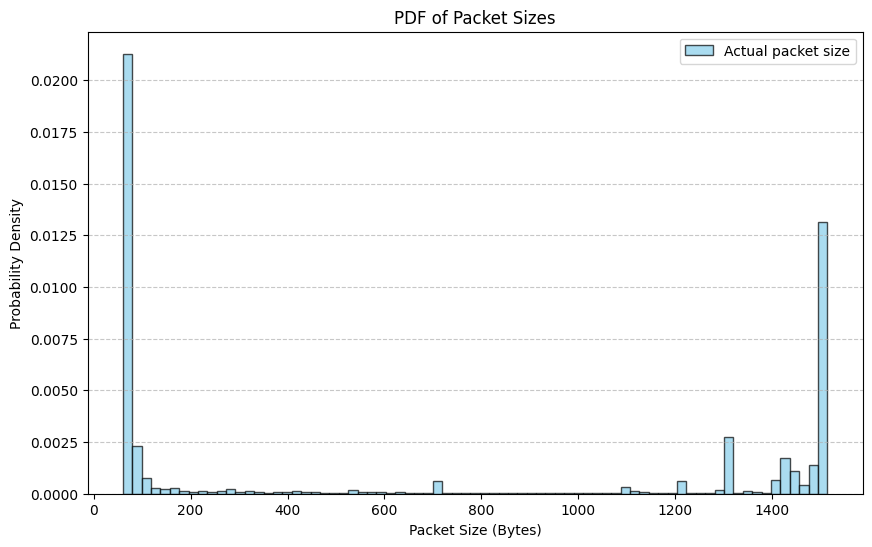

Estimated params: [6.93655380e+01 9.35308560e+00 2.12853291e-02 1.50460822e+03
 9.29202659e+00 1.31281564e-02]
R-squared: 0.9766484217258542
RMSE: 0.0004363376160881193


<Figure size 640x480 with 0 Axes>

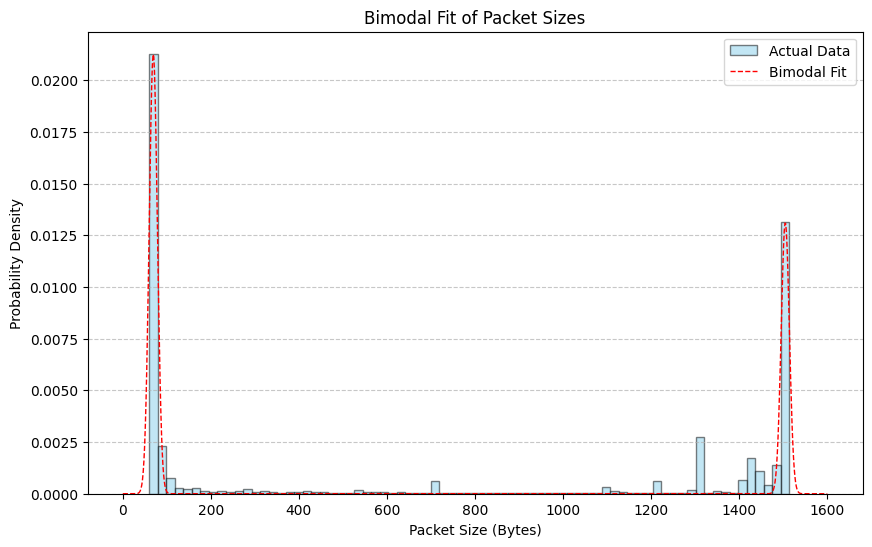

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def rsquared_rmse(predicted_data: np.ndarray, observed_data: np.ndarray) -> float:
    residuals = observed_data - predicted_data
    
    sse = np.sum(residuals ** 2)
    
    sst = np.sum((observed_data - np.mean(observed_data)) ** 2)

    r_squared = 1 - (sse / sst) 
    rmse = np.sqrt(np.mean(residuals**2))
    
    return r_squared, rmse 

# Create the bimodal from the sum of 2 gaussian
def gauss(x,mu,sigma,A):
    return A * np.exp(-(x-mu)**2/2 /sigma**2)

def bimodal(x,mu1,sigma1,A1,mu2,sigma2,A2):
    return gauss(x,mu1,sigma1,A1) + gauss(x,mu2,sigma2,A2)

bins = 75

packet_sizes = df["frame.len"].dropna()

pdf = plt.figure(figsize=(10, 6))

plt.hist(packet_sizes, bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.7, label="Actual packet size")
plt.title('PDF of Packet Sizes')
plt.xlabel('Packet Size (Bytes)')
plt.ylabel('Probability Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Save the single pdf for reference.
plt.savefig("figures/task1/pdf-packet_size.pdf")
plt.close(pdf)

# Create a histogram to get the (x, y) coordinates for fitting
counts, bin_edges = np.histogram(packet_sizes, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Search for Amplitude parameter of the 2 gaussian. LLM helped here
left_zone = bin_centers < 500
peak1_center = bin_centers[left_zone][np.argmax(counts[left_zone])]
peak1_height = np.max(counts[left_zone])

right_zone = bin_centers > 1000
peak2_center = bin_centers[right_zone][np.argmax(counts[right_zone])]
peak2_height = np.max(counts[right_zone])

# Initial guess: needed because curve_fit will give "Parameters not found error"
initial_guess = [peak1_center, 10, peak1_height, peak2_center, 10, peak2_height]

# Specify bound to avoid useless search, constrain to both peaks
lower_bounds = [0,   1,   0,                  1000, 1,   0]          
upper_bounds = [500, 200, peak1_height, 1600, 200, peak2_height] 

# Find optimal parameters
params, cov = curve_fit(
    bimodal, 
    bin_centers, 
    counts, 
    p0=initial_guess, 
    bounds=(lower_bounds, upper_bounds),
    maxfev=10000
)

plt.figure(figsize=(10,6))
# Plot origial data
plt.hist(packet_sizes, bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.5, label="Actual Data")

# Plot the bimodal-distribution
x_range = np.linspace(0, 1600, 1000)
plt.plot(x_range, bimodal(x_range, *params), color='red', linestyle="--", lw=1, label='Bimodal Fit')

plt.title('Bimodal Fit of Packet Sizes')
plt.xlabel('Packet Size (Bytes)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
print("Estimated params:", params)
plt.savefig("figures/task1/bimodalfit-packet-size.pdf")

# Goodness of fit evaluation
y_predicted = bimodal(bin_centers, *params)
y_actual = counts

r_squared, rmse = rsquared_rmse(y_predicted, y_actual)
print("R-squared:", r_squared)
print("RMSE:", rmse)

# Flow analysis
In this section, I perform an analysis at flow level. First, I focus the flow duration.

## Feature extraction
Leveraging, the results from `scripts/prepare_pcap.py`, we can simply aggregate metrics per flow by using the `groupby` method. As in the code, we extract 3 feature and save them in `flow_stats` data frame:

- duration: duration of the flow (from the first to the last packet timestamp registered);
- total bytes: sum of bytes sent over the flow;
- packet count: total number of packets;
- proto: protocol type;

Using the full input, there are $2889591$ flows 

In [32]:
# Compute duration, total bytes and packet count
print("Number of flows detected:", df["flow_id"].max() + 1)
flow_stats = df.groupby("flow_id").agg(
    duration=("frame.time_relative", lambda x: x.max() - x.min()),
    total_bytes=("frame.len", "sum"),
    packet_count=("frame.number", "count"),
    proto=("ip.proto", "first"),
)

flow_stats.head()

Number of flows detected: 2889592


,duration,total_bytes,packet_count,proto
flow_id,,,,
0,132.553151,47034058,31068,6.0
1,720.145928,470,5,1.0
2,899.371219,4180134,66245,6.0
3,140.229038,79134,1196,6.0
4,0.000000,66,1,6.0


## Flow durations analysis
First we plot all the flow durations. To avoid scale problem, I am using $\log_{10}$ scale. At first glance, we notice that the most majority of these connections are very short lived. Looking at the `CDF`, we can understand more than $70%$ of the flows have zero durations.

## Why so many short lived connections?
In my opinion, this is suspect behaviour. I have different hypotheses:
- ICMP noise: most ICMP traffic is for network control;
- UDP protocols: there may be some sort of packet filtering going on;
- TCP broken connection: there can be many TCP partial handshake;

The suspect is that there can be a on going network scan.

To understand the utilization of the network, I would analyze:

- characterize traffic based on the protocol used (TCP, UDP, ICMP etc.);
- compare the duration of TCP flows skipping uncomplete handshake;
- compare the duration of UDP and TCP flows;

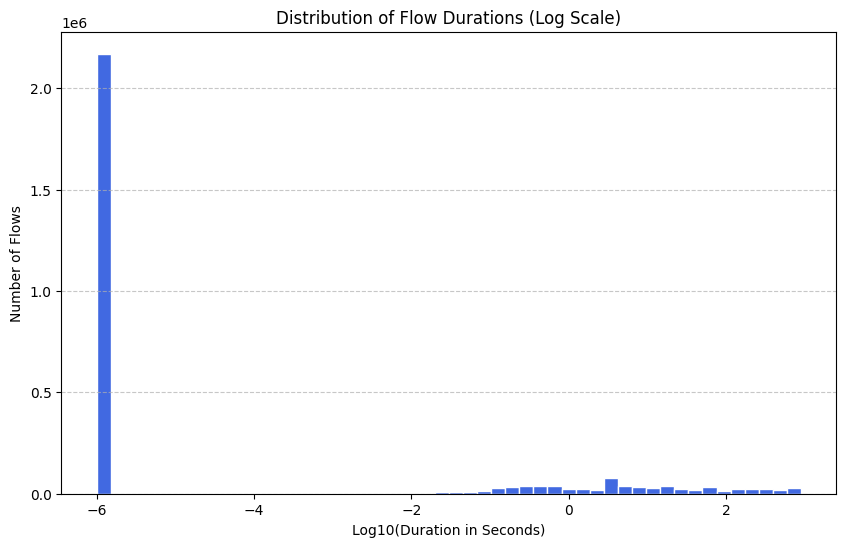

/tmp/ipykernel_5014/2756759501.py:37: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("figures/cdf-flow-durations-all.pdf")
/tmp/ipykernel_5014/2756759501.py:37: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("figures/cdf-flow-durations-all.pdf")
/home/giuseppe/dev/work/imdea-ass/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


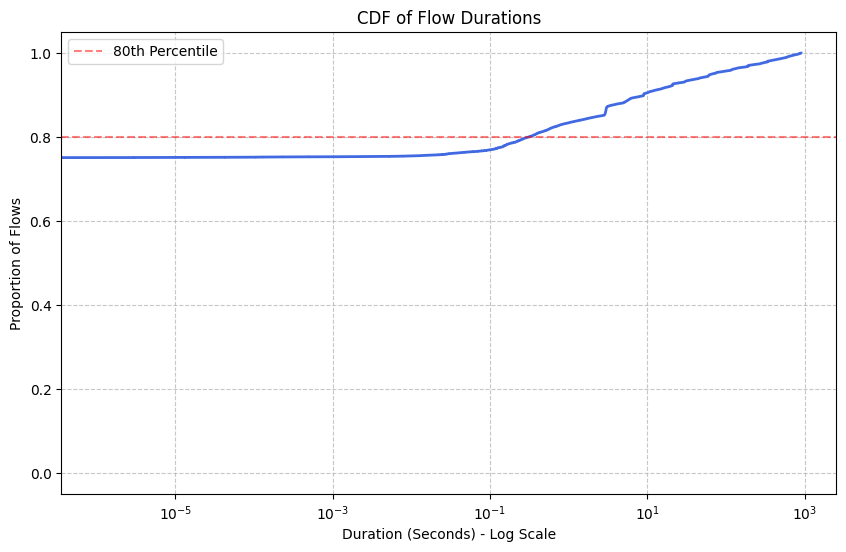

In [33]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Add offset to avoid log10(0)
log_durations = np.log10(flow_stats['duration'] + 1e-6)

# Plot the distribution of the durations
plt.hist(log_durations, bins=50, color='royalblue', edgecolor='white')

plt.title('Distribution of Flow Durations (Log Scale)')
plt.xlabel('Log10(Duration in Seconds)')
plt.ylabel('Number of Flows')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("figures/task1/distribution-flow-durations-all.pdf")
plt.show()

plt.figure(figsize=(10, 6))

# Calculate the CDF
x = np.sort(flow_stats['duration'])

y = np.arange(1, len(x) + 1) / len(x)

plt.step(x, y, where='post', color='royalblue', linewidth=2)

# Set the x-axis to a logarithmic scale
plt.xscale('log')

plt.title('CDF of Flow Durations')
plt.xlabel('Duration (Seconds) - Log Scale')
plt.ylabel('Proportion of Flows')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='80th Percentile')
plt.legend()
plt.savefig("figures/task1/cdf-flow-durations-all.pdf")
plt.show()

## Protocol classification

I performed an analysis for the 3-major protocols. I calculated the percentage of bytes transmitted for each protocol. Looking at plots below:

- ~44% of the traffic is ICMP
- ~31% of the traffic is TCP
- ~19% of the traffic is UDP

Looking at protocol by data, ICMP traffic is less than $1\%$ of the total, while the vast majority of data is exchanged using TCP connections ($~85\%$). While other protocols and UDP use $~13\%$ of the total traffic data (respectively $~7\%$ and $~6\%$).

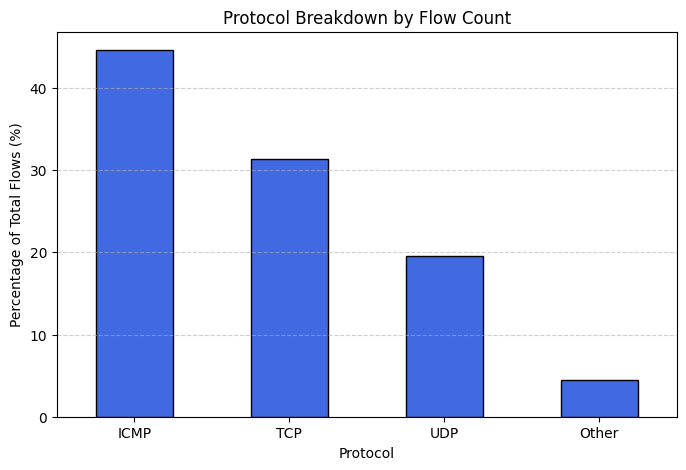

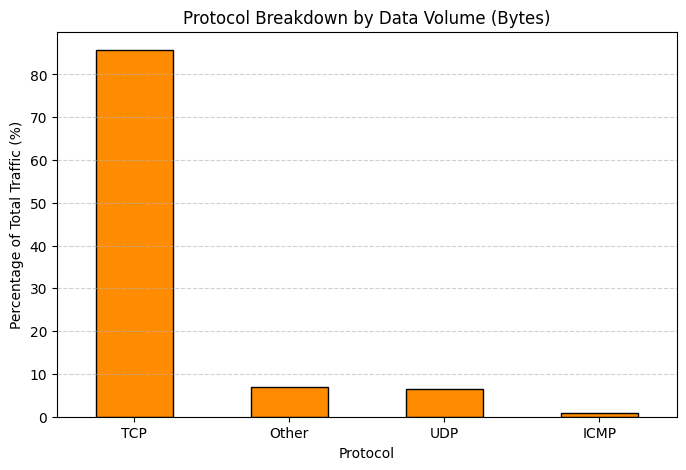

ICMP 44.6007256387753%; ICMP bytes 0.8132273248782872
TCP 31.338611125722938%; TCP bytes 85.69046860129683
UDP 19.541063236609183%; UDP bytes 6.511739004927078
OTHER 4.519599998892578%; UDP bytes 6.984565068897802


In [34]:
import matplotlib.pyplot as plt

proto_map = {6: 'TCP', 17: 'UDP', 1: 'ICMP'}
flow_stats['proto_name'] = flow_stats['proto'].map(proto_map).fillna('Other')

# Count the flows by protocol
proto_counts = flow_stats['proto_name'].value_counts(normalize=True) * 100

# Sum bytes sent per protocol
proto_bytes = flow_stats.groupby('proto_name')['total_bytes'].sum()
proto_bytes_pct = (proto_bytes / proto_bytes.sum()) * 100

# Plot the percentage of protocol
plt.figure(figsize=(8, 5))
proto_counts.plot(kind='bar', color='royalblue', edgecolor='black')
plt.title('Protocol Breakdown by Flow Count')
plt.ylabel('Percentage of Total Flows (%)')
plt.xlabel('Protocol')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig("figures/task1/proto-byflow.pdf")
plt.show()

# Plot the percentage of bytes sent per protocol
plt.figure(figsize=(8, 5))
proto_bytes_pct.sort_values(ascending=False).plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Protocol Breakdown by Data Volume (Bytes)')
plt.ylabel('Percentage of Total Traffic (%)')
plt.xlabel('Protocol')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig("figures/proto-bybytes.pdf")
plt.show()

print(f"ICMP {proto_counts['ICMP']}%; ICMP bytes {proto_bytes_pct['ICMP']}")
print(f"TCP {proto_counts['TCP']}%; TCP bytes {proto_bytes_pct['TCP']}")
print(f"UDP {proto_counts['UDP']}%; UDP bytes {proto_bytes_pct['UDP']}")
print(f"OTHER {proto_counts['Other']}%; UDP bytes {proto_bytes_pct['Other']}")

## TCP analysis

Given that TCP produces $~85\%$ of data in the network and given that the $~70\%$ of the flows in the network have $~0s$ durations, I analyzed the amount of TCP traffic that does not complete the handhshake. 

As shown in the plots below, $~51\%$ of TCP flows contains less than 4 packets. This means that they do either do not complete handshake or just contain a single segment.

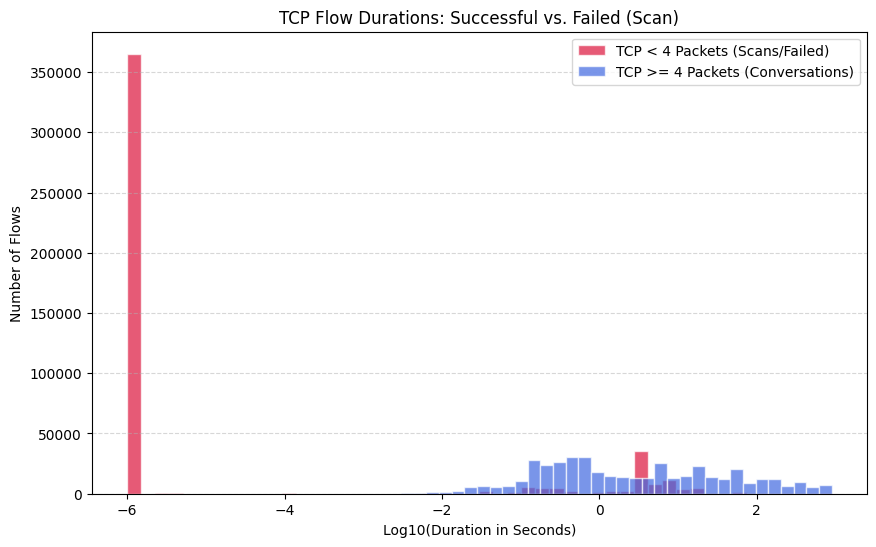

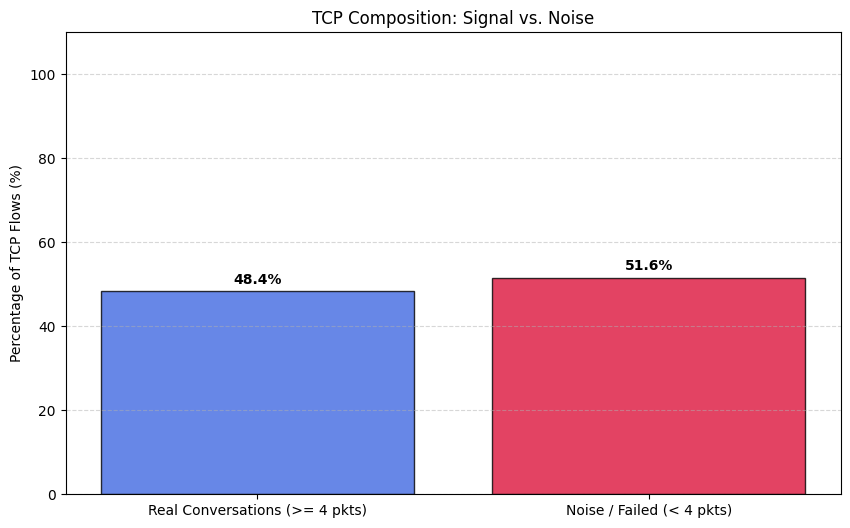

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Get TCP traffic
tcp_all = flow_stats[flow_stats['proto'] == 6]
total_tcp_count = len(tcp_all)

# Split the TCP flows that have completed the 3-way handshake
tcp_real = tcp_all[tcp_all['packet_count'] >= 4]
tcp_noise = tcp_all[tcp_all['packet_count'] < 4]

# Calculate percentage
tcp_real_count = len(tcp_all[tcp_all['packet_count'] >= 4])
tcp_noise_count = len(tcp_all[tcp_all['packet_count'] < 4])

pct_real = (tcp_real_count / total_tcp_count) * 100
pct_noise = (tcp_noise_count / total_tcp_count) * 100

# Calculate durations (avoid log(0))
log_real = np.log10(tcp_real['duration'] + 1e-6)
log_noise = np.log10(tcp_noise['duration'] + 1e-6)

# Plot the 2 distribution
plt.figure(figsize=(10, 6))


plt.hist(log_noise, bins=50, color='crimson', alpha=0.7, 
         label='TCP < 4 Packets (Scans/Failed)', edgecolor='white')

plt.hist(log_real, bins=50, color='royalblue', alpha=0.7, 
         label='TCP >= 4 Packets (Conversations)', edgecolor='white')

plt.title('TCP Flow Durations: Successful vs. Failed (Scan)')
plt.xlabel('Log10(Duration in Seconds)')
plt.ylabel('Number of Flows')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig("figures/task1/tcp-durations-broken-vs-ok.pdf")
plt.show()

# Plot the 2 categories of TCP connection (valid and non-valid)
plt.figure(figsize=(10,6))
categories = ['Real Conversations (>= 4 pkts)', 'Noise / Failed (< 4 pkts)']
percentages = [pct_real, pct_noise]
colors = ['royalblue', 'crimson']

bars = plt.bar(categories, percentages, color=colors, edgecolor='black', alpha=0.8)

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.title('TCP Composition: Signal vs. Noise')
plt.ylabel('Percentage of TCP Flows (%)')
plt.ylim(0, 110) # Leave room for labels
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig("figures/task1/tcp-perc-broken-vs-ok.pdf")
plt.show()

## UDP
Similar to TCP, I calculate the percentage of UDP connection that seem *probe*. These zero durations connections are the $88\%$ of the total. The rest of these connections are long lived and may be legitimate communications. 

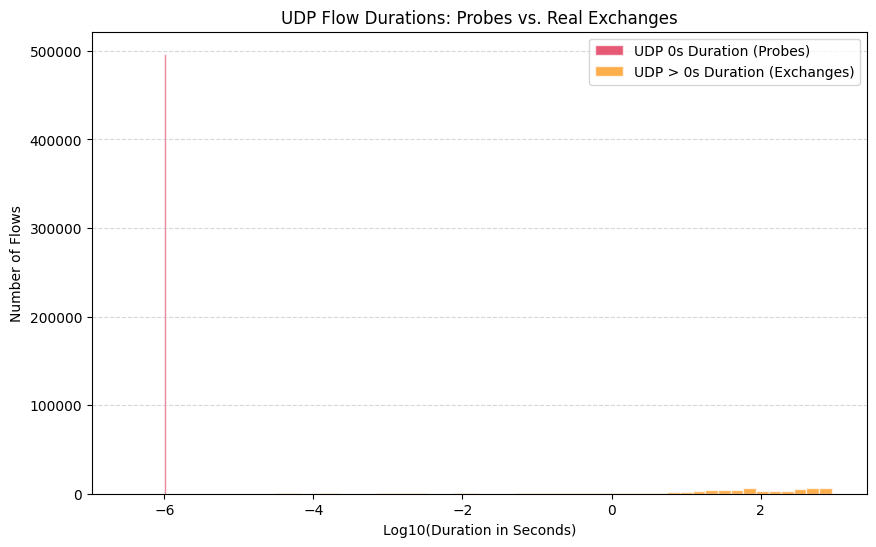

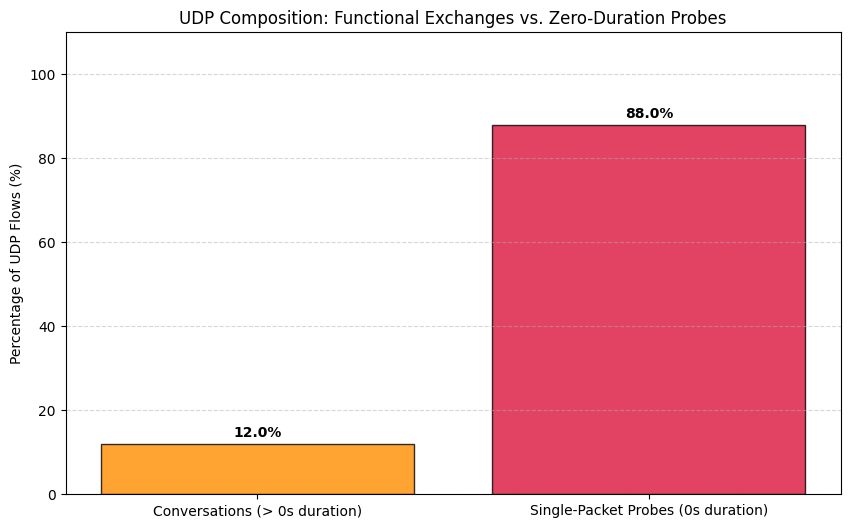

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Get UDP flows
udp_all = flow_stats[flow_stats['proto'] == 17]
total_udp_count = len(udp_all)

#  Split into two groups based on duration
# Zero duration = single packet probe; Non-zero = multi-packet exchange
udp_zero = udp_all[udp_all['duration'] == 0]
udp_real = udp_all[udp_all['duration'] > 0]

# Calculate Percentages
udp_zero_count = len(udp_zero)
udp_real_count = len(udp_real)
pct_zero = (udp_zero_count / total_udp_count) * 100
pct_real = (udp_real_count / total_udp_count) * 100

# Plot the distribution
plt.figure(figsize=(10, 6))

log_real_udp = np.log10(udp_real['duration'] + 1e-6)
log_zero_udp = np.log10(udp_zero['duration'] + 1e-6)

plt.hist(log_zero_udp, bins=50, color='crimson', alpha=0.7, 
         label='UDP 0s Duration (Probes)', edgecolor='white')
plt.hist(log_real_udp, bins=50, color='darkorange', alpha=0.7, 
         label='UDP > 0s Duration (Exchanges)', edgecolor='white')

plt.title('UDP Flow Durations: Probes vs. Real Exchanges')
plt.xlabel('Log10(Duration in Seconds)')
plt.ylabel('Number of Flows')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig("figures/task1/udp-durations-zero-vs-real.pdf")
plt.show()

# Bar Plot: UDP Composition
plt.figure(figsize=(10, 6))
categories = ['Conversations (> 0s duration)', 'Single-Packet Probes (0s duration)']
percentages = [pct_real, pct_zero]
colors = ['darkorange', 'crimson']

bars = plt.bar(categories, percentages, color=colors, edgecolor='black', alpha=0.8)

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.title('UDP Composition: Functional Exchanges vs. Zero-Duration Probes')
plt.ylabel('Percentage of UDP Flows (%)')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig("figures/task1/udp-perc-zero-vs-real.pdf")
plt.show()

# Real network profile

Removing ICMP traffic, invalid TCP connection and invalid UDP $0s$ durations, we can see that the real traffic profile contains "long-lived" TCP connections and some UDP. The following cell shows the duration distribution plot.

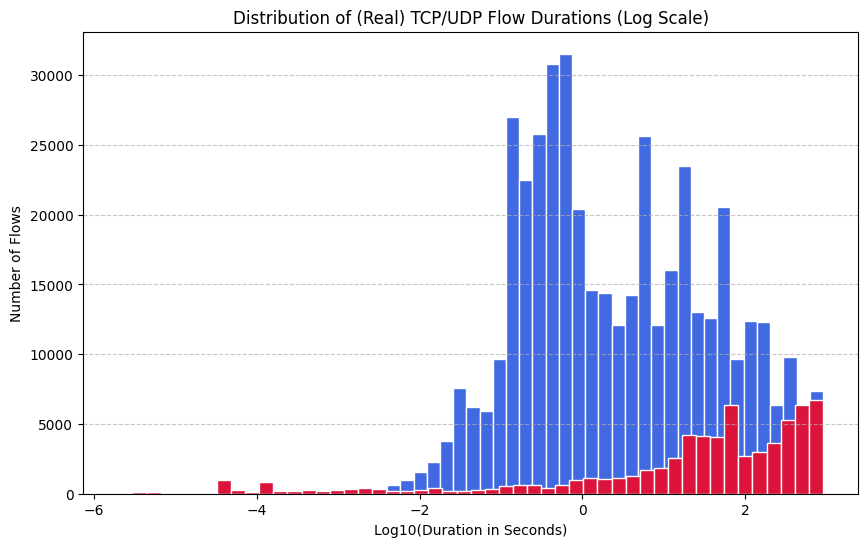

In [37]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Select valid TCP connections
real_tcp = flow_stats[(flow_stats['packet_count'] >= 4) & (flow_stats["proto"] == 6)]
real_udp = flow_stats[(flow_stats["proto"] == 17) & (flow_stats["duration"] > 0)]

# Add offset to avoid log10(0)
real_tcp_log_durations = np.log10(real_tcp["duration"])
real_udp_log_durations = np.log10(real_udp["duration"])

# Plot real tcp duration
plt.hist(real_tcp_log_durations, bins=50, color='royalblue', edgecolor='white')
plt.hist(real_udp_log_durations, bins=50, color='crimson', edgecolor='white')

plt.title('Distribution of (Real) TCP/UDP Flow Durations (Log Scale)')
plt.xlabel('Log10(Duration in Seconds)')
plt.ylabel('Number of Flows')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("figures/task1/distribution-flow-durations-tcpudp.pdf")
plt.show()

## Security considerations
The high volume of ICMP traffic combined with a vast number of incomplete TCP handshakes strongly suggests active network reconnaissance (scanning). The prevalence of zero-second UDP flows further supports this, as they likely represent probes to closed ports. To confirm, Deep Packet Inspection (DPI) or a port-frequency analysis is recommended to identify the specific nature of the UDP and ICMP traffic (e.g., DNS vs. unusual probing).

## Suspicious IP detection
**NOTE**: I know that IP addresses are anonymized, but this analysis leverages the fact that common tools (like `tcpreplay` or `editcap`) use a consistent mapping.

To identify the source of the potential network scan, I analyzed the traffic profile of individual source IPs. The underlying hypothesis is that a network scanner exhibits a highly asymmetric traffic pattern: it initiates a massive number of connections (flows) to probe ports, but transmits virtually no application data.

To test this, I aggregated the data by Source IP (ip.src) to calculate both the total flow count and the total bytes transmitted per host. By comparing the top 10 most active IPs by flow count against the top 10 IPs by data volume, we can isolate the scanner. Any IP that dominates the flow count but is entirely absent from the top data exchangers is mathematically confirmed to be exhibiting scanning behavior.


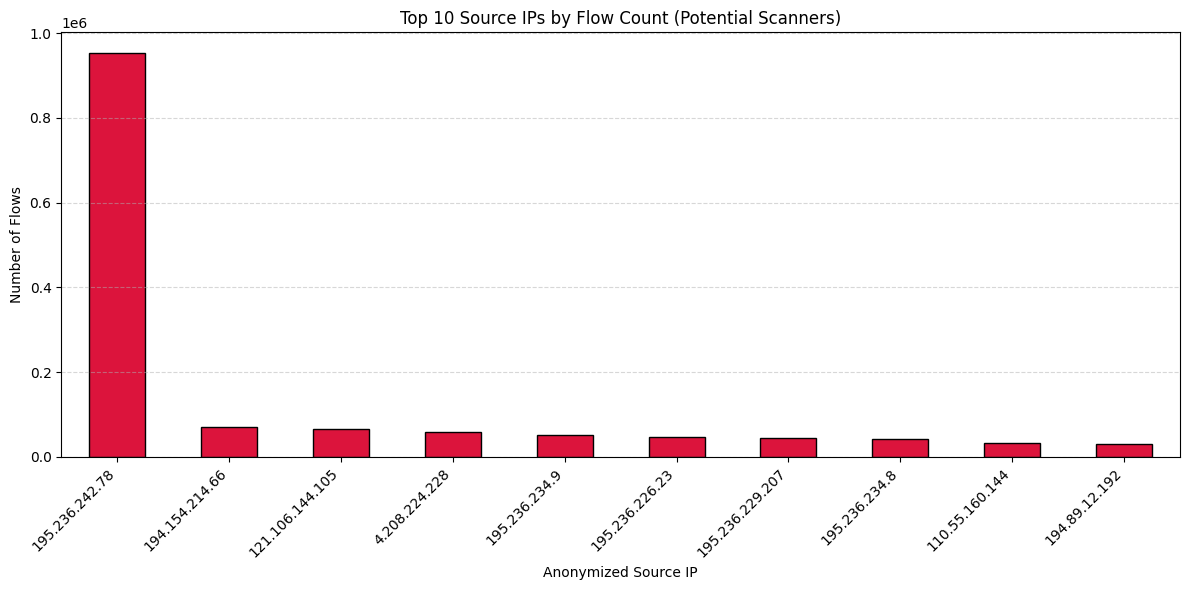

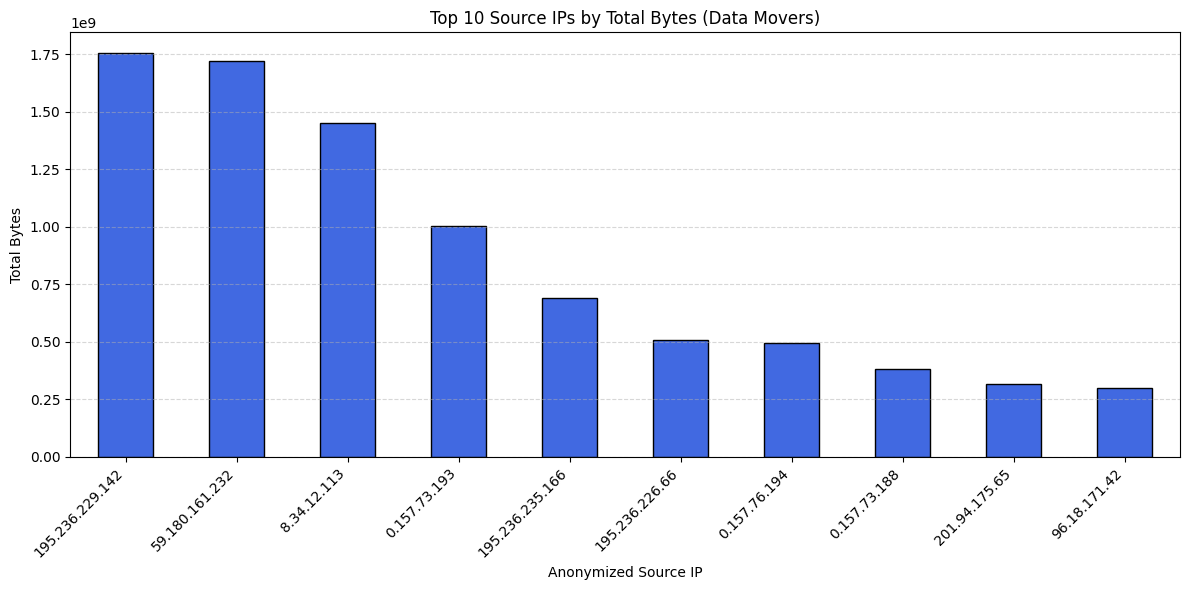

In [38]:
import matplotlib.pyplot as plt

# Group by ip.src and compute the number of flows and the total data sent
ip_stats = df.groupby('ip.src').agg(
    flow_count=('flow_id', 'nunique'),
    total_bytes=('frame.len', 'sum')
)

# Get the first 10 IPs that opened connections
top_flows = ip_stats['flow_count'].sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_flows.plot(kind='bar', color='crimson', edgecolor='black')
plt.title('Top 10 Source IPs by Flow Count (Potential Scanners)')
plt.ylabel('Number of Flows')
plt.xlabel('Anonymized Source IP')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("figures/task1/top10-srcip-flowcount.pdf")
plt.show()

# Get the first 10 IPs that sent bytes
top_bytes = ip_stats['total_bytes'].sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_bytes.plot(kind='bar', color='royalblue', edgecolor='black')
plt.title('Top 10 Source IPs by Total Bytes (Data Movers)')
plt.ylabel('Total Bytes')
plt.xlabel('Anonymized Source IP')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig("figures/task1/top10-srcip-datasent.pdf")
plt.tight_layout()
plt.show()

# Conclusions
The analysis covers a 15-minute snapshot of network traffic containing 2,889,592 flows. Approximately 44% of these flows are ICMP, and 51% of the TCP flows consist of fewer than 4 packets, indicating they did not move meaningful application data. Once this "noise" is filtered, a distinct subset of long-lived connections (10–1000 seconds) emerges, representing the actual functional workload of the network.

Due to the number of invalid connections, a further analysis suggested that there is an network scan.

# In-Network Feature Extraction using P4

This section contains the same analysis performed using extracted features using `tcpreplay` on the `bmv2` target. For performance reason, I cut the original dataset after $100000$ packtes. The CSVs used in this sections are simply collected from the counters of the data-plane.

**NOTE**
When running experiments with $100000$, there is a packet loss $\leq 5\%$ even with `--multiplier=0.01`.

## Packet size analysis
As for the full flow statically processed, the packet size has the same behaviour. I could fit the bimodal distribution again. Using P4 there is a caveat when reading packet size. Since the capture is truncated at 96 bytes, I cannot use `(bit<32>)stdmeta.packet_length` as it will be capped at 96 bytes. I used `hdr.ipv4.totalLen + 14` instead (packet size + frame header size).

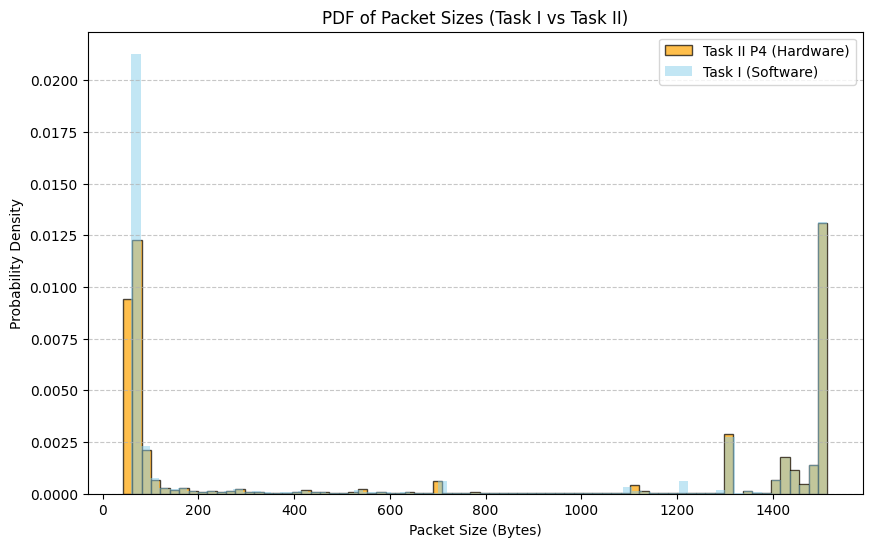

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_p4 = pd.read_csv("dataset/p4_packet_sizes.csv")

# Create the histogram from the P4 counter.
p4_packet_sizes = np.repeat(df_p4['packet_size'].values, df_p4['count'].values)

bins = 75
pdf = plt.figure(figsize=(10, 6))

# Plot the P4 Data
plt.hist(p4_packet_sizes, bins=bins, density=True, color='orange', 
         edgecolor='black', alpha=0.7, label="Task II P4 (Hardware)")

# Plot data from previous cell
plt.hist(packet_sizes, bins=bins, density=True, color='skyblue', alpha=0.5, label="Task I (Software)")

plt.title('PDF of Packet Sizes (Task I vs Task II)')
plt.xlabel('Packet Size (Bytes)')
plt.ylabel('Probability Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.savefig("figures/task2/pdf-packetsize-task1-task2.pdf")
plt.show()

## Flow duration analysis

As in Task 1, the flow duration analysis tells that the vast majority of flows have 0 durations. For TCP connections, this means that there are incompleted handshake; UDP do not have a connection, but we can classify these connection either as **probe** or DNS/NTP queries that have been blocked for some reasons.

By looking at the distributions, the same analysis from Task 1 can be applied

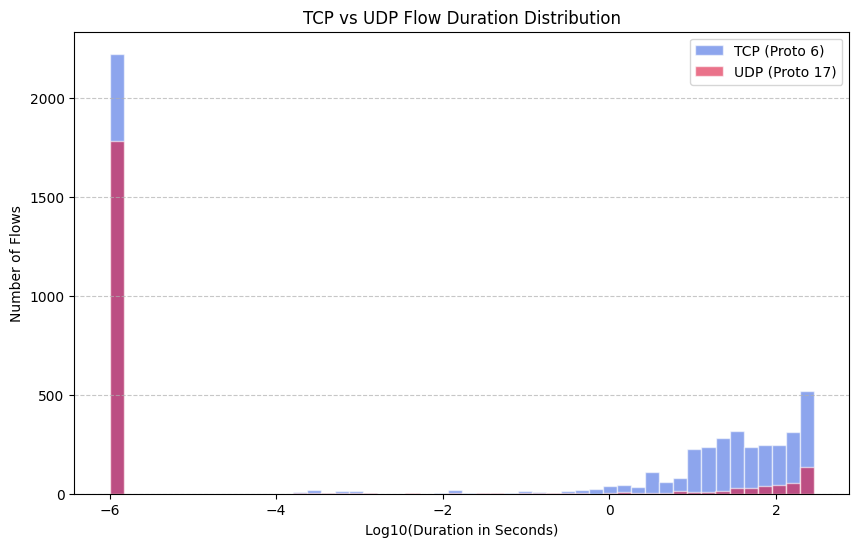

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("dataset/p4_flow_durations.csv")
df['duration_s'] = df['duration_us'] / 1_000_000

# Separate data
tcp_durations = df[df['protocol'] == 6]['duration_s']
udp_durations = df[df['protocol'] == 17]['duration_s']

plt.figure(figsize=(10, 6))

# Plot both distributions
plt.hist(np.log10(tcp_durations + 1e-6), bins=50, alpha=0.6, 
         label='TCP (Proto 6)', color='royalblue', edgecolor='white')
plt.hist(np.log10(udp_durations + 1e-6), bins=50, alpha=0.6, 
         label='UDP (Proto 17)', color='crimson', edgecolor='white')

plt.title('TCP vs UDP Flow Duration Distribution')
plt.xlabel('Log10(Duration in Seconds)')
plt.ylabel('Number of Flows')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("figures/task2/flow-duration.pdf")
plt.show()

# Methodologies comparison: In-Network vs Post-mortem

## Storage efficiency
Using *in-network* methodology shows how efficient can be to perform line rate feature extraction. I did not have to deal with huge PCAP files ($15$ minutes of traffic, generated $~2.5 GB$ PCAP, which in turn took $15$ minutes to parse in CSV). This is not suitable when parsing data and creating distribution fitting since. The `in-network` approach generated 2 tiny CSV ($9.1K$ and $160k$) against the $7.3M$ CSV generated starting from the raw PCAP (first $100000$ packets).

## Detection and Reaction
Also, everything I did in task 1 can be used to do a "post-mortem" analysis, but the "attack" already happened.

As shown above, both methodologies show overall the same results. The main advantage is the ability to control the data-plane during the feature extraction. For example, when dealing with scanner (like in this case) a dedicated firewall rule could be applied to block the IP. Creating a feedback-control loop.

## Programability and Hardware Constraints

The P4 approach is much more strict and complicated. I cannot perform every feature extraction that i want in Python, but in P4 we have to deal with registers and counters and the communication with the control-plane. 

However, SmartNICs have limitated resources and cannot handle complex workloads. In P4, everything is stateless and we need to rely on registers to create state (which is the main difficulty when handling flows).